In [1]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import logging
from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from collections import defaultdict
import pandas as pd
from manifold.decoding.functions.utils import check_config_decoding
import numpy as np
import pickle as pkl
from manifold.decoding.functions import nulldistributions
from communication_subspace.ibl_communication.utils import load_widefield_epoch
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import warnings
from matplotlib import pyplot as plt
warnings.filterwarnings("ignore")
from manifold.utils import get_trial_masks
from glob import glob
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
import statsmodels.stats.multitest as smm
import seaborn as sns

In [3]:
%load_ext autoreload 
%autoreload 2

### Imbalanced ppi

In [207]:
files = glob('../data/generated/wifi/ppis/*.pkl')

In [216]:
# build combined df
df = []
for idx,f in enumerate(files):
    data_session = pkl.load(open(f,'rb'))
    data_session['animal-id'] = idx
    df.append(data_session)

In [217]:
combined_df = pd.concat(df)

In [222]:
combined_df['seed'] = combined_df['seed'].str[0]
combined_df['target'] = combined_df['target'].str[0]

In [223]:
grouped = combined_df.groupby(['condition', 'seed', 'target'])

In [224]:
def compute_group_level_ppi(combined_df, min_animals=3):
    results = []
    
    
    grouped = combined_df.groupby(['condition', 'seed', 'target'])
    
    for (condition, seed, target), group_data in grouped:
        
    
        betas = group_data['interaction_beta'].dropna().values
        
        n_animals = len(betas)
        
    
        if n_animals < min_animals:
            continue
            
    
        t_stat, p_val = ttest_1samp(betas, popmean=0)
        mean_beta = np.mean(betas)
        sem_beta = np.std(betas, ddof=1) / np.sqrt(n_animals)
        
        results.append({
            'condition': condition,
            'seed': seed,
            'target': target,
            'mean_beta': mean_beta,
            'sem_beta': sem_beta,
            't_stat': t_stat,
            'p_val_raw': p_val,
            'n_animals': n_animals
        })
        
    results_df = pd.DataFrame(results)
    final_dfs = []
    
    for condition in results_df['condition'].unique():
        cond_df = results_df[results_df['condition'] == condition].copy()
        
        reject, pvals_corrected, _, _ = smm.multipletests(
            cond_df['p_val_raw'], alpha=0.05, method='fdr_bh'
        )
        
        cond_df['p_val_fdr'] = pvals_corrected
        cond_df['is_significant'] = reject
        final_dfs.append(cond_df)
        
    final_results = pd.concat(final_dfs, ignore_index=True)
    final_results = final_results.sort_values(by=['condition', 'p_val_fdr'])
    
    return final_results

In [225]:
population_ppi_results = compute_group_level_ppi(combined_df)

In [247]:
sig_results = population_ppi_results[population_ppi_results['condition'] == 'congruence']
sig_results.loc[~sig_results['is_significant'], 'mean_beta'] = 0

In [248]:
matrix = sig_results.pivot(index='seed', columns='target', values='mean_beta')

<Axes: xlabel='target', ylabel='seed'>

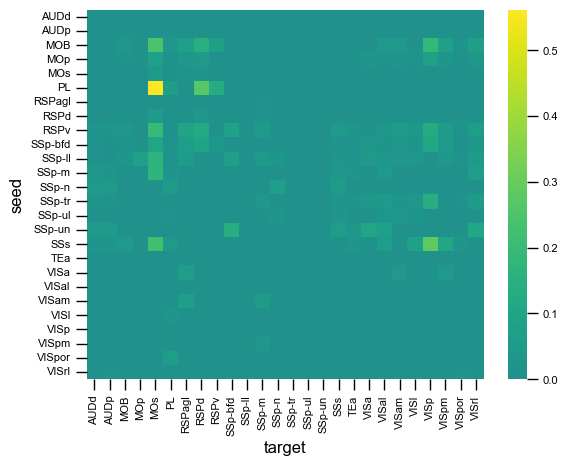

In [249]:
sns.heatmap(matrix, cmap='viridis', center=0)

In [273]:
# get MOS, PL
from manifold.widefield_ppi import return_labels


session_id = sessions_all[0]
one = ONE(mode="local")
ssl = SessionLoader(one, sessions_all[0])
ssl.load_trials(collection="alf")
trials = ssl.trials.copy()
config = check_config_decoding()
out = np.nan_to_num(trials.contrastLeft) - np.nan_to_num(trials.contrastRight)
trials["signcont"] = out
trials["stim_side"] = np.sign(trials["signcont"])

_, stimulus_behavioral_mask = load_trials_and_mask(
        one,
        session_id,
        exclude_nochoice=False,
        exclude_unbiased=False,
    )
stimulus_non_zero_mask = trials["signcont"] != 0
stim_mask = stimulus_behavioral_mask & stimulus_non_zero_mask
_, choice_behavioral_mask = load_trials_and_mask(
        one,
        session_id,
        exclude_nochoice=True,
        exclude_unbiased=False,
    )
choice_mask = choice_behavioral_mask
combined_mask = choice_mask & stim_mask

stim_data, stim_region_names = load_widefield_epoch(one, session_id, trials, config["hemisphere"], epoch="stim", regions=[["PL"]])
choice_data, choice_region_names = load_widefield_epoch(one, session_id, trials, config["hemisphere"], epoch="choice", response_time=True, regions=[["MOs"]])

# stim is frame2 - frame1
# choice is frame2
session_results = []
terms = "congruence"
labels, conditions = return_labels(trials, terms)
final_mask = combined_mask & conditions
labels_masked = labels[final_mask]

In [274]:
from manifold.widefield_ppi import compute_ppi_interaction


stim_frame = stim_data[0][:, final_mask, :]
stim_frame = stim_frame[1,:] - stim_frame[0,:] # do the delta 
choice_frame = choice_data[0][:, final_mask, :]
choice_frame = choice_frame[1,:]
results = compute_ppi_interaction(Y=choice_frame, X=stim_frame, labels=labels_masked, reduction="PCA")

In [275]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
stim_pca = pca.fit_transform(stim_frame).squeeze()
choice_pca = pca.fit_transform(choice_frame).squeeze()

In [279]:

plot_df = pd.DataFrame({
    'PL': stim_pca,
    'MOs': choice_pca,
    'Condition': ['Congruent' if c == 1 else 'Incongruent' for c in labels_masked]
})

<Figure size 600x500 with 0 Axes>

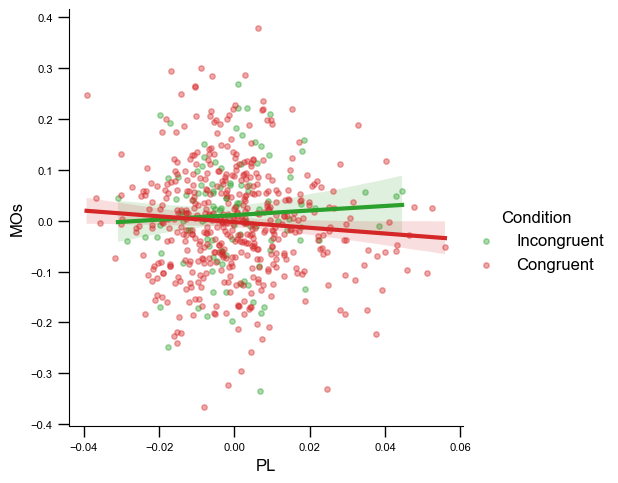

In [ ]:

plot_df = pd.DataFrame({
    'PL': stim_pca,
    'MOs': choice_pca,
    'Condition': ['Congruent' if c == 1 else 'Incongruent' for c in labels_masked]
})
plt.figure(figsize=(6, 5))
sns.lmplot(
    data=plot_df,
    x='PL',
    y='MOs',
    hue='Condition',
    palette=['#2ca02c', '#d62728'],
    scatter_kws={'alpha': 0.4, 's': 15},
    line_kws={'linewidth': 3}
)


### Balanced ppi

In [2]:
files = glob("../data/generated/wifi/ppis/deltaframe/*.pkl")

In [3]:
# build combined df
df = []
for idx,f in enumerate(files):
    data_session = pkl.load(open(f,'rb'))
    data_session['animal-id'] = idx
    df.append(data_session)

In [4]:
combined_df = pd.concat(df)
combined_df['seed'] = combined_df['seed']
combined_df['target'] = combined_df['target']

In [5]:
grouped = combined_df.groupby(['condition', 'seed', 'target'])

In [6]:
def compute_group_level_ppi(combined_df, min_animals=3):
    subject_means = combined_df.groupby(
        ['animal-id', 'condition', 'seed', 'target']
    )['interaction_beta'].mean().reset_index()
    results = []
    
    
    grouped = subject_means.groupby(['condition', 'seed', 'target'])
    
    for (condition, seed, target), group_data in grouped:
        
    
        betas = group_data['interaction_beta'].dropna().values
        
        n_animals = len(betas)
        
    
        if n_animals < min_animals:
            continue
            
    
        t_stat, p_val = ttest_1samp(betas, popmean=0)
        mean_beta = np.mean(betas)
        sem_beta = np.std(betas, ddof=1) / np.sqrt(n_animals)
        
        results.append({
            'condition': condition,
            'seed': seed,
            'target': target,
            'mean_beta': mean_beta,
            'sem_beta': sem_beta,
            't_stat': t_stat,
            'p_val_raw': p_val,
            'n_animals': n_animals
        })
        
    results_df = pd.DataFrame(results)
    final_dfs = []
    
    for condition in results_df['condition'].unique():
        cond_df = results_df[results_df['condition'] == condition].copy()
        
        reject, pvals_corrected, _, _ = smm.multipletests(
            cond_df['p_val_raw'], alpha=0.05, method='fdr_bh'
        )
        
        cond_df['p_val_fdr'] = pvals_corrected
        cond_df['is_significant'] = reject
        final_dfs.append(cond_df)
        
    final_results = pd.concat(final_dfs, ignore_index=True)
    final_results = final_results.sort_values(by=['condition', 'p_val_fdr'])
    
    return final_results

In [7]:
population_ppi_results = compute_group_level_ppi(combined_df)

In [8]:
sig_results = population_ppi_results[population_ppi_results['condition'] == 'congruence']
sig_results.loc[~sig_results['is_significant'], 'mean_beta'] = 0

In [173]:
sig_results

,condition,seed,target,mean_beta,sem_beta,t_stat,p_val_raw,n_animals,p_val_fdr,is_significant
12,congruence,MO,PL,0.004472,0.001193,3.750057,0.000574,40,0.025170,True
21,congruence,MOB,PL,0.028613,0.007650,3.740169,0.000621,38,0.025170,True
11,congruence,MO,MOB,0.000000,0.001969,3.192474,0.002788,40,0.075269,False
10,congruence,MO,MO,0.000000,0.012541,2.914624,0.005872,40,0.118096,False
23,congruence,MOB,RSP,0.000000,0.054833,2.771081,0.008601,39,0.118096,False
...,...,...,...,...,...,...,...,...,...,...
31,congruence,PL,PTLp,0.000000,0.131160,-0.152261,0.880884,17,0.926644,False
6,congruence,AUD,SS,0.000000,0.377220,0.068281,0.946240,21,0.958068,False
24,congruence,MOB,SS,0.000000,0.074198,-0.076736,0.939236,39,0.958068,False
64,congruence,TEa,MO,0.000000,0.186169,-0.075727,0.940056,37,0.958068,False


In [174]:
(sig_results[sig_results['is_significant']])[['condition','seed','target','mean_beta','p_val_fdr']]

,condition,seed,target,mean_beta,p_val_fdr
12,congruence,MO,PL,0.004472,0.02517
21,congruence,MOB,PL,0.028613,0.02517


In [10]:
from communication_subspace.ibl_communication.visualize_ppi_dynamics import get_session_and_masks,get_ppi_data,  aggregate_region_signal

In [41]:
# for session with significance
# load data
# aggregate
# then plot

In [11]:
with open("../data/processed/significant_stims_choice.pkl",'rb') as f:
    significant_preloads = pkl.load(f)

In [12]:
from manifold.widefield_ppi import beryl_mapping


parent_mapping = beryl_mapping()

In [13]:
valid_keys = []
for k in significant_preloads.keys():
    results = significant_preloads[k]
    target_subset_stim = set(['MOs','MOp','MOB'])
    target_subset_choice = set(['PL'])
    stim = results['stim']
    choice = results['choice']
    stim_set = set(stim)
    choice_set = set(choice)

    if target_subset_choice.issubset(choice) & target_subset_stim.issubset(stim):
        valid_keys.append(k)

In [144]:
session_id = "32c0dc1e-0b30-493c-a27e-50bfcd0378cc"

In [145]:
one, session_id, trials, congruent_mask, incongruent_mask = get_session_and_masks(session_id)


2026-07-02 16:34:54,832 [INFO] Using session: 32c0dc1e-0b30-493c-a27e-50bfcd0378cc
2026-07-02 16:34:54,929 [INFO] Total Congruent trials: 724
2026-07-02 16:34:54,930 [INFO] Total Incongruent trials: 169


In [146]:
stim_frames = [-1, 6]
source_signal = get_ppi_data(one, session_id, trials, "MO", trials['stimOn_times'], stim_frames, False,  ("left", "right"), use_beryl=True)

2026-07-02 16:34:56,778 [INFO] Aggregating MO from subregions: ['MOp', 'MOs']
2026-07-02 16:34:56,779 [INFO] Loading MO data...


In [147]:
source_signal_alternate = get_ppi_data(one, session_id, trials, "MOB", trials['stimOn_times'], stim_frames, False,  ("left", "right"), use_beryl=True)

2026-07-02 16:35:52,894 [INFO] Aggregating MOB from subregions: ['MOB']
2026-07-02 16:35:52,895 [INFO] Loading MOB data...


In [148]:
source_signal_alternate = source_signal_alternate.transpose(1,0,2)

In [149]:
choice_frames = [-6, 1]
target_signal = get_ppi_data(one, session_id, trials, "PL", trials['response_times'], choice_frames, False,  ("left", "right"), use_beryl=True)

2026-07-02 16:38:53,580 [INFO] Aggregating PL from subregions: ['PL']
2026-07-02 16:38:53,581 [INFO] Loading PL data...


In [150]:
source_signal = source_signal.transpose(1,0,2)
target_signal = target_signal.transpose(1,0,2)

In [151]:
source_cong_mean, source_cong_sd = aggregate_region_signal(source_signal, congruent_mask, use_pca=True)
source_incong_mean, source_incong_sd = aggregate_region_signal(source_signal, incongruent_mask, use_pca=True)

target_cong_mean, target_cong_sd = aggregate_region_signal(target_signal, congruent_mask, use_pca=True)
target_incong_mean, target_incong_sd = aggregate_region_signal(target_signal, incongruent_mask, use_pca=True)

In [152]:
time_choice_rel_stim = trials['response_times'] - trials['stimOn_times']
time_stim_rel_choice = -(trials['stimOn_times'] - trials['response_times'])

In [153]:
frame_duration = 0.066
source_time_axis = np.arange(stim_frames[0], stim_frames[1] + 1) * frame_duration
target_time_axis = np.arange(choice_frames[0], choice_frames[1] + 1) * frame_duration

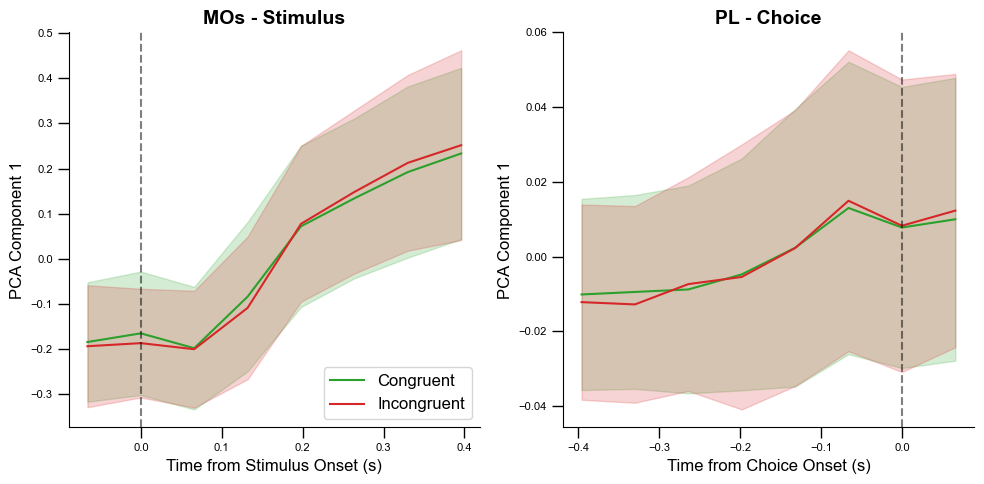

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
color_cong = '#2ca02c'
color_incong = '#d62728'
use_pca=True
y_label = 'PCA Component 1' if use_pca else 'Mean Voxel Activation ($\Delta$F/F)'

ax = axes[0]
ax.plot(source_time_axis, source_cong_mean, color=color_cong, label='Congruent')
ax.fill_between(source_time_axis, source_cong_mean - source_cong_sd/2, source_cong_mean + source_cong_sd/2, color=color_cong, alpha=0.2)
ax.plot(source_time_axis, source_incong_mean, color=color_incong, label='Incongruent')
ax.fill_between(source_time_axis, source_incong_mean - source_incong_sd/2, source_incong_mean + source_incong_sd/2, color=color_incong, alpha=0.2)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_title("MOs - Stimulus", fontsize=14)
ax.set_ylabel(y_label)
ax.set_xlabel("Time from Stimulus Onset (s)")
ax.legend()
sns.despine(ax=ax)

ax = axes[1]
ax.plot(target_time_axis, target_cong_mean, color=color_cong, label='Congruent')
ax.fill_between(target_time_axis, target_cong_mean - target_cong_sd, target_cong_mean + target_cong_sd, color=color_cong, alpha=0.2)
ax.plot(target_time_axis, target_incong_mean, color=color_incong, label='Incongruent')
ax.fill_between(target_time_axis, target_incong_mean - target_incong_sd, target_incong_mean + target_incong_sd, color=color_incong, alpha=0.2)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_title("PL - Choice", fontsize=14)
ax.set_ylabel(y_label)
ax.set_xlabel("Time from Choice Onset (s)")
sns.despine(ax=ax)

sns.despine(ax=ax)
plt.tight_layout()

In [155]:
source_cong_alternate_mean, source_cong_alternate_sd = aggregate_region_signal(source_signal_alternate, congruent_mask, use_pca=True)
source_incong_alternate_mean, source_incong_alternate_sd = aggregate_region_signal(source_signal_alternate, incongruent_mask, use_pca=True)

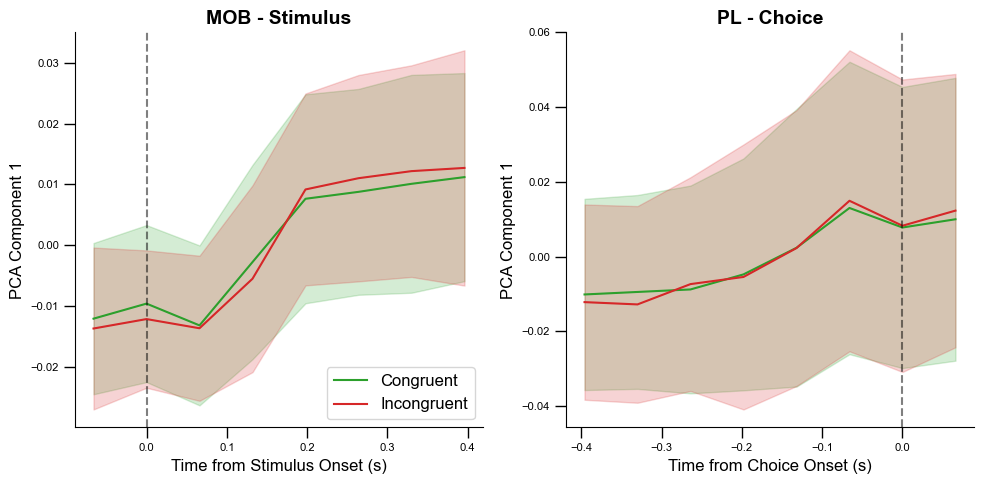

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
color_cong = '#2ca02c'
color_incong = '#d62728'
use_pca=True
y_label = 'PCA Component 1' if use_pca else 'Mean Voxel Activation ($\Delta$F/F)'

ax = axes[0]
ax.plot(source_time_axis, source_cong_alternate_mean, color=color_cong, label='Congruent')
ax.fill_between(source_time_axis, source_cong_alternate_mean - source_cong_alternate_sd/2, source_cong_alternate_mean + source_cong_alternate_sd/2, color=color_cong, alpha=0.2)
ax.plot(source_time_axis, source_incong_alternate_mean, color=color_incong, label='Incongruent')
ax.fill_between(source_time_axis, source_incong_alternate_mean - source_incong_alternate_sd/2, source_incong_alternate_mean + source_incong_alternate_sd/2, color=color_incong, alpha=0.2)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_title("MOB - Stimulus", fontsize=14)
ax.set_ylabel(y_label)
ax.set_xlabel("Time from Stimulus Onset (s)")
ax.legend()
sns.despine(ax=ax)

ax = axes[1]
ax.plot(target_time_axis, target_cong_mean, color=color_cong, label='Congruent')
ax.fill_between(target_time_axis, target_cong_mean - target_cong_sd, target_cong_mean + target_cong_sd, color=color_cong, alpha=0.2)
ax.plot(target_time_axis, target_incong_mean, color=color_incong, label='Incongruent')
ax.fill_between(target_time_axis, target_incong_mean - target_incong_sd, target_incong_mean + target_incong_sd, color=color_incong, alpha=0.2)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_title("PL - Choice", fontsize=14)
ax.set_ylabel(y_label)
ax.set_xlabel("Time from Choice Onset (s)")
sns.despine(ax=ax)

sns.despine(ax=ax)
plt.tight_layout()

In [183]:
%matplotlib inline
import matplotlib.pyplot as plt

In [184]:
labels = np.where(congruent_mask, 1, np.where(incongruent_mask, -1, 0))

<Figure size 600x500 with 0 Axes>

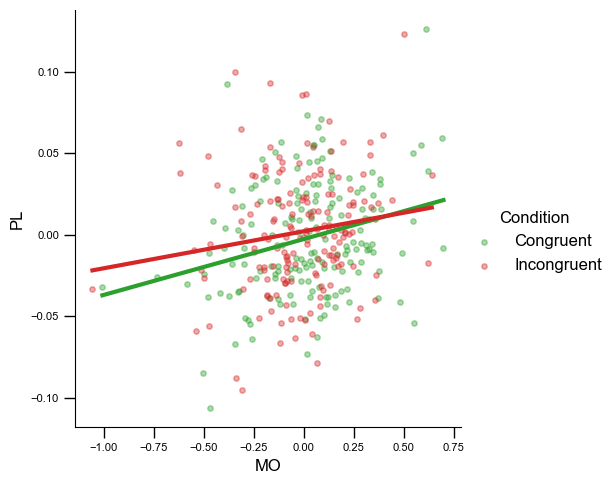

In [186]:
pca = PCA(n_components=1)
stim_pca = pca.fit_transform(source_signal[1,:,:]).squeeze()
choice_pca = pca.fit_transform(target_signal[-1,:,:]).squeeze()
idx_cong = np.where(labels == 1)[0]
idx_incong = np.where(labels == -1)[0]

min_trials = min(len(idx_cong), len(idx_incong))


np.random.seed(42) # Optional: for reproducible plots
sub_cong = np.random.choice(idx_cong, min_trials, replace=False)
sub_incong = np.random.choice(idx_incong, min_trials, replace=False)
balanced_indices = np.concatenate([sub_cong, sub_incong])
np.random.shuffle(balanced_indices)

balanced_stim = stim_pca[balanced_indices]
balanced_choice = choice_pca[balanced_indices]
balanced_labels = labels[balanced_indices]

plot_df = pd.DataFrame({
    'PL': balanced_choice,
    'MO': balanced_stim,
    'Condition': ['Congruent' if c == 1 else 'Incongruent' for c in balanced_labels]
})


plt.figure(figsize=(6, 5))
sns.lmplot(
    data=plot_df,
    x='MO',
    y='PL',
    hue='Condition',
    palette=['#2ca02c', '#d62728'],
    scatter_kws={'alpha': 0.4, 's': 15},
    line_kws={'linewidth': 3},
    ci=None
)
plt.savefig('./temp_mo_pl.png')

<Figure size 600x500 with 0 Axes>

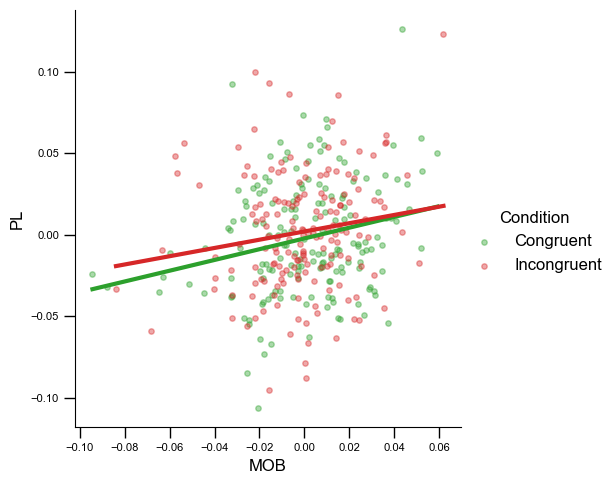

In [187]:
pca = PCA(n_components=1)
stim_pca = pca.fit_transform(source_signal_alternate[1,:,:]).squeeze()
choice_pca = pca.fit_transform(target_signal[-1,:,:]).squeeze()
idx_cong = np.where(labels == 1)[0]
idx_incong = np.where(labels == -1)[0]

min_trials = min(len(idx_cong), len(idx_incong))


np.random.seed(42) # Optional: for reproducible plots
sub_cong = np.random.choice(idx_cong, min_trials, replace=False)
sub_incong = np.random.choice(idx_incong, min_trials, replace=False)
balanced_indices = np.concatenate([sub_cong, sub_incong])
np.random.shuffle(balanced_indices)

balanced_stim = stim_pca[balanced_indices]
balanced_choice = choice_pca[balanced_indices]
balanced_labels = labels[balanced_indices]

plot_df = pd.DataFrame({
    'PL': balanced_choice,
    'MOB': balanced_stim,
    'Condition': ['Congruent' if c == 1 else 'Incongruent' for c in balanced_labels]
})


plt.figure(figsize=(6, 5))
sns.lmplot(
    data=plot_df,
    x='MOB',
    y='PL',
    hue='Condition',
    palette=['#2ca02c', '#d62728'],
    scatter_kws={'alpha': 0.4, 's': 15},
    line_kws={'linewidth': 3},
    ci=None
)
plt.savefig('./temp_mo_pl.png')

In [124]:
df = []
for idx,f in enumerate(files):
    data_session = pkl.load(open(f,'rb'))
    data_session['animal-id'] = f.rsplit('/')[-1].rsplit("_")[0]
    df.append(data_session)
new_combined_df = pd.concat(df)

In [126]:
session_id

np.str_('f7d46a15-9498-40dc-90da-fb977ce844be')

In [134]:
mob_pl = new_combined_df[(new_combined_df['seed']=='MOB') & (new_combined_df['target']=="PL")]
mo_pl = new_combined_df[(new_combined_df['seed']=='MO') & (new_combined_df['target']=="PL")]

In [139]:
mo_pl_means =  mo_pl.groupby(
        ['animal-id', 'condition', 'seed', 'target']
    )['interaction_beta'].mean().reset_index()

mob_pl_means =  mob_pl.groupby(
        ['animal-id', 'condition', 'seed', 'target']
    )['interaction_beta'].mean().reset_index()

### Congruence PPI (Correct/Incorrect congruence)

In [2]:
from manifold.widefield_stats import compute_complete_df, compute_group_level_ppi

In [ ]:
files0 = glob("../data/generated/wifi/ppis/singleframe_congruence/frame0/*.pkl")
files1 = glob("../data/generated/wifi/ppis/singleframe_congruence/frame1/*.pkl")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_df(significant_df):
    df = significant_df.copy()
    # df = df[df['seed'] != 'AUD']

    seeds = df['seed'].unique()
    n_seeds = len(seeds)


    cols = 3
    rows = math.ceil(n_seeds / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharey=True)
    axes = axes.flatten() # Flatten to make indexing easier

    for i, seed in enumerate(seeds):

        ax = axes[i]
        subset = df[df['seed'] == seed].sort_values('mean_beta', ascending=False)
        
        ax.bar(subset['target'], subset['mean_beta'], yerr=subset['sem_beta'], 
            capsize=5, color='#4C72B0', edgecolor='black', alpha=0.8)
        
        ax.set_title(f'Seed: {seed}', fontweight='bold', fontsize=12)
        ax.set_ylabel('Mean Beta')
        ax.axhline(0, color='black', linewidth=1) # Adds a baseline at zero
        
        ax.tick_params(axis='x', rotation=90)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('PPI Effect', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [6]:
def run_the_gamut(files, condition):
    complete_df_0 = compute_complete_df(files)
    stats_df_0 = compute_group_level_ppi(complete_df_0)

    sig_results_0 = stats_df_0[stats_df_0['condition'] == condition]
    sig_results_0.loc[~sig_results_0['is_significant'], 'mean_beta'] = 0
    significant_df = sig_results_0[sig_results_0['is_significant']]

    return significant_df


In [5]:
files = glob('../data/generated/wifi/ppis/correctness/frame1/*.pkl')

In [7]:
significant_df = run_the_gamut(files, 'correctness')

In [11]:
significant_df.to_csv('../data/generated/wifi/spatial_alignment/significant_pairs.csv')

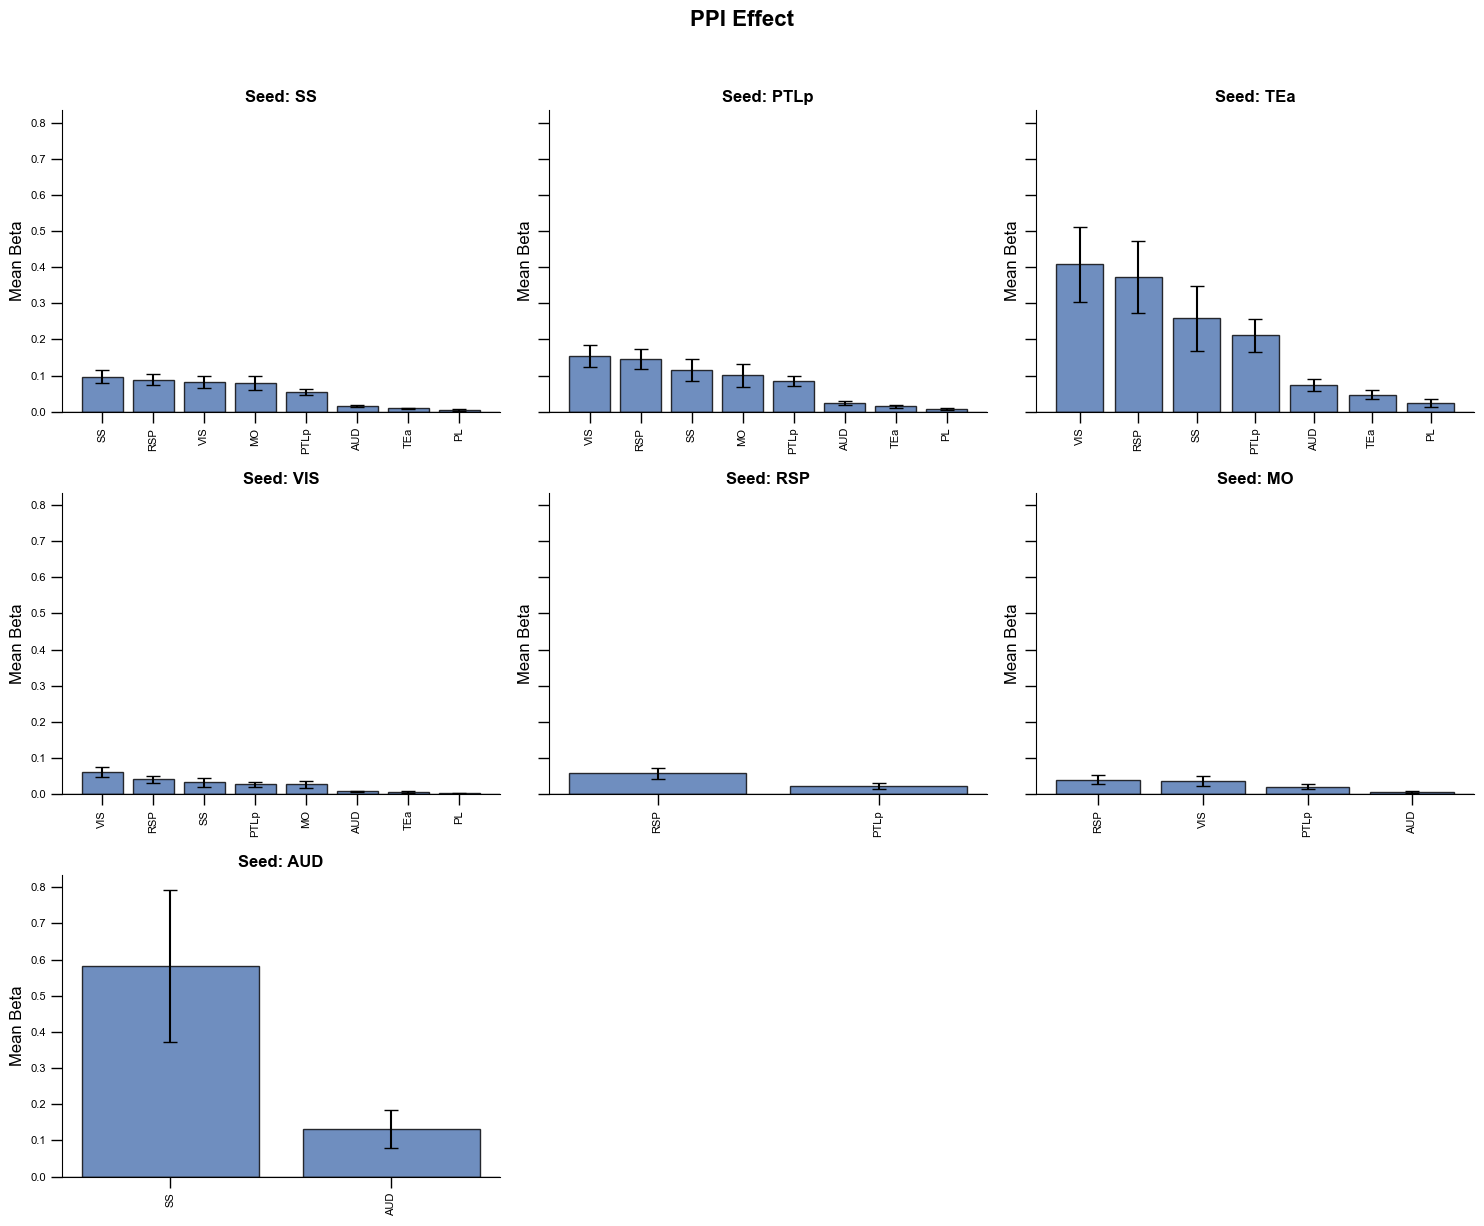

In [18]:
plot_df(significant_df)

In [15]:
complete_df_0 = compute_complete_df(files)
stats_df_0 = compute_group_level_ppi(complete_df_0)